In [ ]:
# What This Project Is About

# You're going to work with airline ticket data (route, price, booking date, travel date, season, etc.) and answer three real business questions:

# How do prices vary by route? (some routes are just pricier, why?)
# How do prices vary by booking time? (does booking 2 months early actually save money, or is that a myth?)
# How do prices vary by season? (do prices spike around holidays, summer, etc.?)

In [ ]:
import pandas as pd
df = pd.read_csv('Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1.0,5953.0
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5953.0
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1.0,5956.0
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1.0,5955.0
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5955.0


In [ ]:
print(df.shape)
df.info()

(91555, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91555 entries, 0 to 91554
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        91555 non-null  int64  
 1   airline           91555 non-null  object 
 2   flight            91555 non-null  object 
 3   source_city       91555 non-null  object 
 4   departure_time    91555 non-null  object 
 5   stops             91555 non-null  object 
 6   arrival_time      91555 non-null  object 
 7   destination_city  91554 non-null  object 
 8   class             91554 non-null  object 
 9   duration          91554 non-null  float64
 10  days_left         91554 non-null  float64
 11  price             91554 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 8.4+ MB


In [ ]:
print(df[df['price'].isnull()])

       Unnamed: 0  airline  flight source_city departure_time stops  \
91554       91554  Vistara  UK-854   Bangalore        Evening   one   

      arrival_time destination_city class  duration  days_left  price  
91554            M              NaN   NaN       NaN        NaN    NaN  


In [ ]:
df_clean = df.dropna(subset=['price'])
print(df_clean.shape)

(91554, 12)


In [ ]:
df_clean.drop(columns=['Unnamed: 0'], inplace=True)

/tmp/ipykernel_2239/2137626400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns=['Unnamed: 0'], inplace=True)


In [ ]:
df_clean = df.dropna(subset=['price']).copy()
df_clean.drop(columns=['Unnamed: 0'], inplace=True)
print(df_clean.shape)
print(df_clean.columns)

(91554, 11)
Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')


In [12]:
df_clean['route'] = df_clean['source_city'] + " to " + df_clean['destination_city']

In [13]:
df_clean['route'].value_counts().head(10)

,count
route,
Delhi to Bangalore,10144
Delhi to Mumbai,9982
Mumbai to Delhi,9801
Mumbai to Kolkata,8774
Mumbai to Bangalore,8706
Delhi to Kolkata,8654
Delhi to Chennai,7666
Bangalore to Delhi,7489
Mumbai to Hyderabad,6990


In [14]:
df_clean.groupby('route')['price'].mean()

,price
route,
Bangalore to Delhi,6699.191748
Delhi to Bangalore,6175.622535
Delhi to Chennai,6102.317245
Delhi to Hyderabad,6031.164261
Delhi to Kolkata,7045.621678
Delhi to Mumbai,6059.826087
Mumbai to Bangalore,6432.511946
Mumbai to Chennai,6420.917984
Mumbai to Delhi,5889.281400


In [15]:
df_clean.groupby('route')['price'].mean().sort_values(ascending=False)

,price
route,
Mumbai to Kolkata,7227.971735
Delhi to Kolkata,7045.621678
Bangalore to Delhi,6699.191748
Mumbai to Bangalore,6432.511946
Mumbai to Chennai,6420.917984
Delhi to Bangalore,6175.622535
Delhi to Chennai,6102.317245
Delhi to Mumbai,6059.826087
Delhi to Hyderabad,6031.164261


In [16]:
route_prices = df_clean.groupby('route')['price'].mean().sort_values(ascending=False)
print(route_prices.head(5))
print(route_prices.tail(5))

route
Mumbai to Kolkata      7227.971735
Delhi to Kolkata       7045.621678
Bangalore to Delhi     6699.191748
Mumbai to Bangalore    6432.511946
Mumbai to Chennai      6420.917984
Name: price, dtype: float64
route
Delhi to Chennai       6102.317245
Delhi to Mumbai        6059.826087
Delhi to Hyderabad     6031.164261
Mumbai to Delhi        5889.281400
Mumbai to Hyderabad    5774.891130
Name: price, dtype: float64


In [17]:
df_clean[df_clean['route'] == 'Mumbai to Kolkata']['duration'].mean()
df_clean[df_clean['route'] == 'Mumbai to Hyderabad']['duration'].mean()

np.float64(13.14620886981402)

In [18]:
print(df_clean[df_clean['route'] == 'Mumbai to Kolkata']['duration'].mean())
print(df_clean[df_clean['route'] == 'Mumbai to Hyderabad']['duration'].mean())

12.324644403920676
13.14620886981402


In [19]:
df_clean.groupby('stops')['price'].mean().sort_values(ascending=False)

,price
stops,
two_or_more,8960.277766
one,6628.651092
zero,4115.838795


In [20]:
df_clean['days_left'].corr(df_clean['price'])

np.float64(-0.5663168498565682)

In [21]:
df_clean.groupby('days_left')['price'].mean().sort_values().head(10)

,price
days_left,
47.0,4506.727538
48.0,4518.583236
46.0,4536.952161
32.0,4553.190869
33.0,4591.172329
40.0,4599.175594
49.0,4604.916570
41.0,4615.132190
42.0,4625.169154


In [22]:
df_clean.groupby('days_left')['price'].mean().sort_values(ascending=False).head(10)

,price
days_left,
1.0,14032.451256
2.0,12734.890865
3.0,12288.597865
9.0,11065.545564
10.0,11003.654135
8.0,10425.753899
4.0,10363.914541
7.0,10316.763946
5.0,10253.379612


In [24]:
df_clean.groupby('airline')['price'].mean().sort_values(ascending=False)

,price
airline,
Vistara,7302.539278
Air_India,6960.234349
SpiceJet,6231.627154
GO_FIRST,5606.694327
Indigo,5516.441456
AirAsia,4400.923346


In [25]:
df_clean.groupby('airline')['class'].value_counts(normalize=True)

,,proportion
airline,class,
AirAsia,Economy,1.0
Air_India,Economy,1.0
GO_FIRST,Economy,1.0
Indigo,Economy,1.0
SpiceJet,Economy,1.0
Vistara,Economy,1.0


In [26]:
df_clean.groupby('airline')['class'].value_counts(normalize=True).sort_index()

,,proportion
airline,class,
AirAsia,Economy,1.0
Air_India,Economy,1.0
GO_FIRST,Economy,1.0
Indigo,Economy,1.0
SpiceJet,Economy,1.0
Vistara,Economy,1.0


In [27]:
pd.crosstab(df_clean['airline'], df_clean['class'], normalize='index')

class,Economy
airline,
AirAsia,1.0
Air_India,1.0
GO_FIRST,1.0
Indigo,1.0
SpiceJet,1.0
Vistara,1.0


In [28]:
df_clean['class'].unique()

array(['Economy'], dtype=object)

In [29]:
df_business = pd.read_csv('business.csv')
print(df_business.shape)
df_business.head()

(93487, 11)


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"


In [30]:
df_business = df_business.rename(columns={
    'from': 'source_city',
    'to': 'destination_city',
    'stop': 'stops',
    'time_taken': 'duration'
})
print(df_business.columns)

Index(['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'source_city',
       'duration', 'stops', 'arr_time', 'destination_city', 'price'],
      dtype='object')


In [31]:
df_business['class'] = 'Business'

In [32]:
df_business['class'].unique()

array(['Business'], dtype=object)

In [33]:
df_business['stops'].unique()

array(['non-stop ',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IDR\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IXU\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Chennai\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Lucknow\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia STV\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Hyderabad\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia GAY\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '2+-stop',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Guwahati\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia GAU\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia VTZ\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia NDC\n\t\t\t\t\t\t\t\t\t\t\t\t',
       '1-stop\n\t\t\t\t\t\t\t\t\t\t\t

In [34]:
df_business['stops'] = df_business['stops'].str.strip().str[:8]
df_business['stops'].unique()

array(['non-stop', '1-stop', '1-stop\n\t', '2+-stop'], dtype=object)

In [35]:
df_business['stops'] = df_business['stops'].str.split('\n').str[0].str.strip()
df_business['stops'].unique()

array(['non-stop', '1-stop', '2+-stop'], dtype=object)

In [36]:
df_business['stops'] = df_business['stops'].map({
    'non-stop': 'zero',
    '1-stop': 'one',
    '2+-stop': 'two_or_more'
})
df_business['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [37]:
df_business['duration'].head(10)

,duration
0,02h 00m
1,02h 15m
2,24h 45m
3,26h 30m
4,06h 40m
5,02h 10m
6,17h 45m
7,22h 45m
8,17h 55m
9,02h 15m


In [38]:
hours = df_business['duration'].str.extract(r'(\d+)h').astype(float)
minutes = df_business['duration'].str.extract(r'(\d+)m').astype(float)
df_business['duration'] = hours[0] + minutes[0] / 60
df_business['duration'].head(10)

,duration
0,2.000000
1,2.250000
2,24.750000
3,26.500000
4,6.666667
5,2.166667
6,17.750000
7,22.750000
8,17.916667
9,2.250000


In [40]:
import numpy as np

In [41]:
df_business['flight'] = df_business['ch_code'] + '-' + df_business['num_code'].astype(str)
df_business['days_left'] = np.nan
df_business = df_business.drop(columns=['ch_code', 'num_code', 'dep_time', 'arr_time'])
print(df_business.columns)

Index(['date', 'airline', 'source_city', 'duration', 'stops',
       'destination_city', 'price', 'class', 'flight', 'days_left'],
      dtype='object')


In [42]:
df_business['route'] = df_business['source_city'] + " to " + df_business['destination_city']
df_business['route'].head()

,route
0,Delhi to Mumbai
1,Delhi to Mumbai
2,Delhi to Mumbai
3,Delhi to Mumbai
4,Delhi to Mumbai


In [43]:
df_full = pd.concat([df_clean, df_business], ignore_index=True)
print(df_full.shape)
print(df_full['class'].value_counts())

(185041, 13)
class
Business    93487
Economy     91554
Name: count, dtype: int64


In [44]:
df_full.groupby('class')['price'].mean()

TypeError: agg function failed [how->mean,dtype->object]

In [45]:
df_full['price'].dtype

dtype('O')

In [46]:
df_full['price'] = df_full['price'].astype(str).str.replace(',', '').astype(float)
df_full['price'].dtype

dtype('float64')

In [47]:
df_full.groupby('class')['price'].mean()

,price
class,
Business,52540.081124
Economy,6353.699161


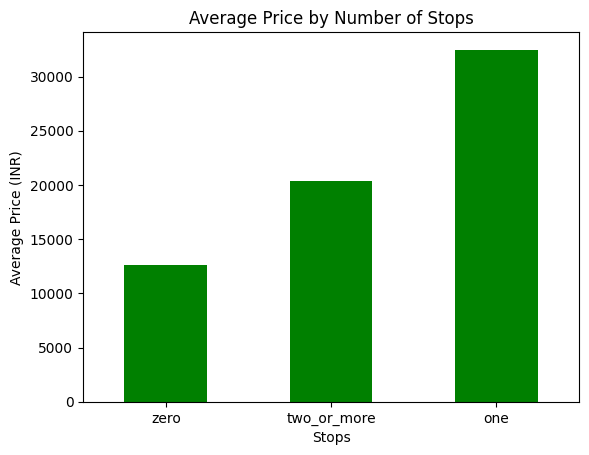

In [49]:
import matplotlib.pyplot as plt

stop_prices = df_full.groupby('stops')['price'].mean().sort_values()
stop_prices.plot(kind='bar', color='Green')
plt.title('Average Price by Number of Stops')
plt.ylabel('Average Price (INR)')
plt.xlabel('Stops')
plt.xticks(rotation=0)
plt.show()

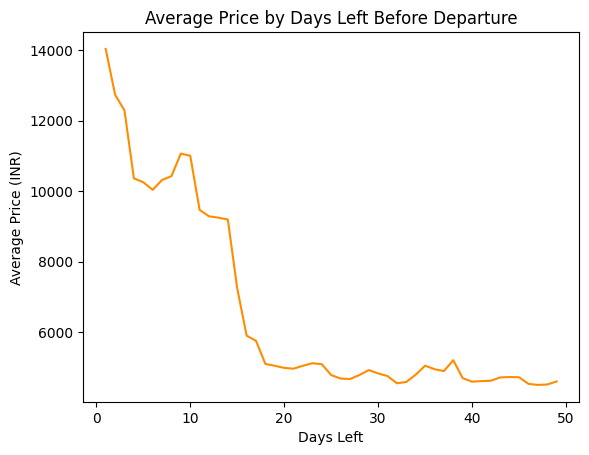

In [50]:
days_prices = df_full.groupby('days_left')['price'].mean()
days_prices.plot(kind='line', color='darkorange')
plt.title('Average Price by Days Left Before Departure')
plt.ylabel('Average Price (INR)')
plt.xlabel('Days Left')
plt.show()

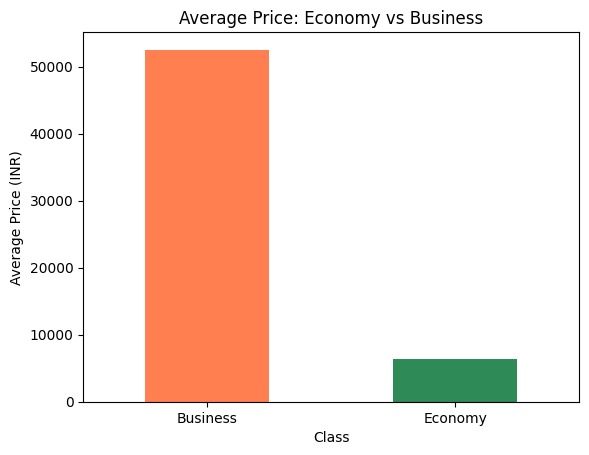

In [51]:
class_prices = df_full.groupby('class')['price'].mean()
class_prices.plot(kind='bar', color=['coral', 'seagreen'])
plt.title('Average Price: Economy vs Business')
plt.ylabel('Average Price (INR)')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.show()

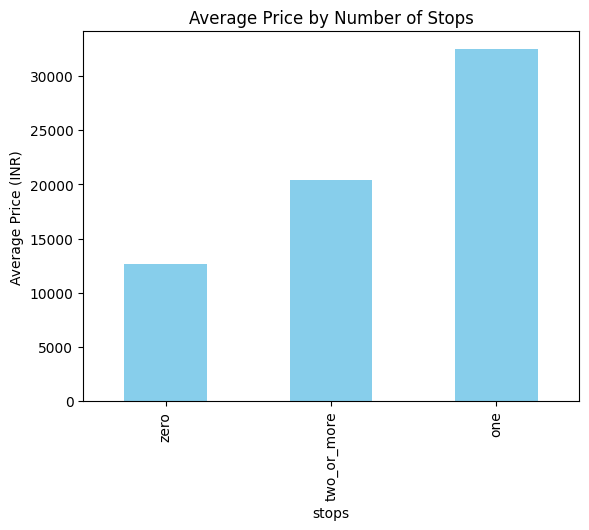

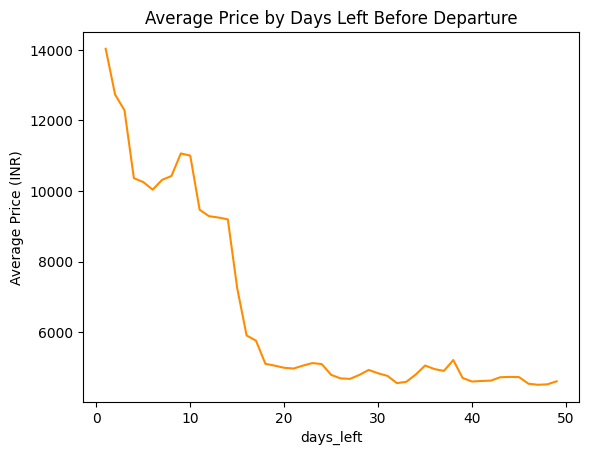

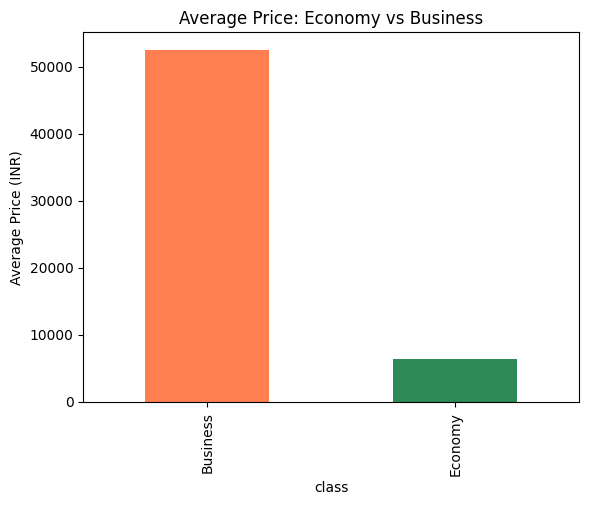

In [52]:
stop_prices.plot(kind='bar', color='skyblue')
plt.title('Average Price by Number of Stops')
plt.ylabel('Average Price (INR)')
plt.savefig('price_by_stops.png', bbox_inches='tight')
plt.show()

days_prices.plot(kind='line', color='darkorange')
plt.title('Average Price by Days Left Before Departure')
plt.ylabel('Average Price (INR)')
plt.savefig('price_by_days_left.png', bbox_inches='tight')
plt.show()

class_prices.plot(kind='bar', color=['coral', 'seagreen'])
plt.title('Average Price: Economy vs Business')
plt.ylabel('Average Price (INR)')
plt.savefig('price_by_class.png', bbox_inches='tight')
plt.show()